# Step 2: Exploratory Data Analysis
## Horizon-Aware Startup Outcome Prediction

## 2.1 Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import (FORBIDDEN, FOUNDING_SAFE, FIRST_FUNDING_SAFE, 
                         SNAPSHOT_ALL, LEAK_REGISTRY, FUNDING_ROUND_COLS)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

SEED = 42
FIGURE_DIR = '../figures'

# Load raw data
df_raw = pd.read_csv('../investments_VC 2.csv', encoding='latin-1')
df_raw.columns = df_raw.columns.str.strip()
print(f"Raw CSV: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# Drop fully blank rows
df = df_raw.dropna(how='all').copy()
print(f"After dropping blank rows: {df.shape[0]} rows ({df_raw.shape[0] - df.shape[0]} blanks removed)")

Raw CSV: 54294 rows, 39 columns
After dropping blank rows: 49438 rows (4856 blanks removed)


## 2.2 Data Audit

Before any plots — systematic data quality checks:
- Count blank rows, duplicate entities (by permalink)
- Identify malformed numeric strings in `funding_total_usd`
- Check impossible dates (`first_funding_at < founded_at`)
- Quantify missingness per column
- Check label availability

### 2.2.1 Shape, Types, and Head

The raw CSV has 54,294 rows and 39 columns. Of these, 4,856 are fully blank rows (all columns NaN) — likely artefacts of the CSV export. After removing them, 49,438 rows remain.

In [2]:
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes.value_counts())
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (49438, 39)

Column dtypes:
float64    23
str        16
Name: count, dtype: int64

First 3 rows:


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.2.2 Blank Rows and Duplicates

- 4,856 fully blank rows removed above
- 2 genuine duplicate pairs found by `permalink` (Prysm × 2, Treasure Valley Urology Services × 2 = 4 duplicate rows)
- The 4,860 "duplicate" permalinks include the 4,856 blank-row NaN permalinks plus 4 real duplicate rows (2 pairs)

In [3]:
# Duplicate check by permalink
dup_mask = df['permalink'].duplicated(keep=False) & df['permalink'].notna()
print(f"Rows with duplicate permalink (excluding NaN): {dup_mask.sum()}")
if dup_mask.sum() > 0:
    print("\nDuplicate entries:")
    display(df[dup_mask].sort_values('permalink')[['permalink', 'name', 'status', 'country_code']])

Rows with duplicate permalink (excluding NaN): 4

Duplicate entries:


,permalink,name,status,country_code
33939,/organization/prysm,Prysm,operating,NaN
33940,/organization/prysm,Prysm,operating,USA
44033,/organization/treasure-valley-urology-services,Treasure Valley Urology Services,operating,USA
44034,/organization/treasure-valley-urology-services,Treasure Valley Urology Services,operating,USA


### 2.2.3 Missingness Summary

Missingness is concentrated in three tiers:
- **High missingness (22–39%):** `state_code` (39.0% — expected, most startups are non-US), `founded_*` fields (22%)
- **Moderate missingness (7–12%):** `city` (12.4%), `region` and `country_code` (10.7%), `market` and `category_list` (8.0%), `homepage_url` (7.0%)
- **Low missingness:** `status` (2.7% — 1,314 rows with no label, excluded from modelling alongside operating firms), `name` (1 row)
- **Zero missingness:** All 26 funding and identifier columns are fully populated after blank row removal

In [4]:
# Missingness summary — raw 39 columns only (before any derivation)
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
miss_df = miss_df[miss_df['missing_count'] > 0]
print(f"Columns with missing values: {len(miss_df)} out of {len(df.columns)}")
display(miss_df)

Columns with missing values: 13 out of 39


,missing_count,missing_pct
state_code,19277,39.0
founded_quarter,10956,22.2
founded_month,10956,22.2
founded_year,10956,22.2
founded_at,10884,22.0
city,6116,12.4
region,5273,10.7
country_code,5273,10.7
market,3968,8.0
category_list,3961,8.0


### 2.2.4 Malformed Numeric Values

The `funding_total_usd` column has several issues:
- **Leading/trailing whitespace** in all 49,438 non-blank values
- **Indian-style comma formatting** (e.g., `" 17,50,000 "` = 1,750,000; `" 49,12,393 "` = 4,912,393) — commas do NOT follow Western 3-digit grouping
- **Dash `"-"` for missing/zero** in 8,531 rows — these represent unfunded or undisclosed amounts
- The column is stored as `object` dtype and must be parsed before numeric analysis

In [5]:
# Parse funding_total_usd
def parse_funding(val):
    """Strip whitespace, remove commas, handle dash as NaN."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s in ['-', '', 'nan']:
        return np.nan
    s = s.replace(',', '').replace(' ', '')
    try:
        return float(s)
    except ValueError:
        return np.nan

df['funding_total_clean'] = df['funding_total_usd'].apply(parse_funding)

ftd_str = df['funding_total_usd'].astype(str).str.strip()
print(f"funding_total_usd breakdown:")
print(f"  NaN (blank rows already removed):  {df['funding_total_usd'].isna().sum()}")
print(f"  Dash '-':                           {(ftd_str == '-').sum()}")
print(f"  Contains commas:                    {ftd_str.str.contains(',', na=False).sum()}")
print(f"  Successfully parsed to numeric:     {df['funding_total_clean'].notna().sum()}")
print(f"  Parsed as zero:                     {(df['funding_total_clean'] == 0).sum()}")
print(f"\nParsed stats:")
print(df['funding_total_clean'].describe())

funding_total_usd breakdown:
  NaN (blank rows already removed):  0
  Dash '-':                           8531
  Contains commas:                    40865
  Successfully parsed to numeric:     40907
  Parsed as zero:                     0

Parsed stats:
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_clean, dtype: float64


### 2.2.5 Impossible Dates

The EDA code below counts 2,745 rows with `first_funding_at` earlier than `founded_at` using raw date parsing (including out-of-range dates like year 0020). The cleaning pipeline in `src/preprocessing.py` first sets 10 out-of-range `first_funding_at` dates to NaT, then flags 2,739 impossible dates — this is the definitive count used throughout the report. These rows require quarantining or careful handling in the data preparation step. Many appear to have imprecise founding dates (e.g., `2010-01-01` as a placeholder for "sometime in 2010") where the actual founding preceded the recorded date.

In [6]:
# Parse dates and check for impossible lags
df['founded_dt'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['first_funding_dt'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['last_funding_dt'] = pd.to_datetime(df['last_funding_at'], errors='coerce')

both_valid = df['founded_dt'].notna() & df['first_funding_dt'].notna()
neg_lag = (df['first_funding_dt'][both_valid] < df['founded_dt'][both_valid]).sum()
print(f"Rows with both dates valid: {both_valid.sum()}")
print(f"Rows with first_funding_at < founded_at: {neg_lag} ({neg_lag/both_valid.sum()*100:.1f}%)")
print(f"\nSample impossible dates:")
impossible = df[both_valid & (df['first_funding_dt'] < df['founded_dt'])]
display(impossible[['name', 'founded_at', 'first_funding_at', 'status']].head(8))

Rows with both dates valid: 38554
Rows with first_funding_at < founded_at: 2745 (7.1%)

Sample impossible dates:


,name,founded_at,first_funding_at,status
2,'Rock' Your Paper,2012-10-26,2012-08-09,operating
20,1000memories,2010-07-01,2010-01-01,acquired
54,140 Proof,2010-01-11,2009-07-01,operating
68,1calendar,2009-01-19,2008-04-04,operating
73,1DayLater,2009-08-26,2009-05-01,operating
77,1EQ,2013-03-08,2012-07-01,operating
88,1st Choice Lawn Care,2012-08-01,2012-07-22,operating
92,1V1 DRAFT GAEMS,2014-09-19,2014-08-28,operating


### 2.2.6 Label Distribution

- `operating`: 41,829 pre-dedup (41,827 after the cleaning pipeline removes 2 duplicate operating rows) — excluded as right-censored
- `acquired`: 3,692 (7.5%) — positive class
- `closed`: 2,603 (5.3%) — negative class
- Missing status: 1,314 (2.7%) — excluded (no label)
- **Terminal subset: 6,295 startups (59:41 acquired:closed split)**

*Note: The code output below shows pre-dedup counts (41,829). The cleaning pipeline in Phase 3 deduplicates by permalink, removing 2 operating rows → 41,827. All report-level references use the pipeline count (41,827).*

In [7]:
# Label distribution and terminal subset
print("Status distribution:")
print(df['status'].value_counts(dropna=False))

# Create terminal subset for visual EDA
terminal = df[df['status'].isin(['acquired', 'closed'])].copy()
terminal['target'] = (terminal['status'] == 'acquired').astype(int)
print(f"\nTerminal subset: {len(terminal)} rows")
print(f"  Acquired: {terminal['target'].sum()} ({terminal['target'].mean()*100:.1f}%)")
print(f"  Closed:   {(1-terminal['target']).sum().astype(int)} ({(1-terminal['target'].mean())*100:.1f}%)")

Status distribution:
status
operating    41829
acquired      3692
closed        2603
NaN           1314
Name: count, dtype: int64

Terminal subset: 6295 rows
  Acquired: 3692 (58.6%)
  Closed:   2603 (41.4%)


## 2.3 Visual EDA

Minimum 12 publication-quality figures.

### 2.3.1 Target Distribution (acquired vs closed vs operating)

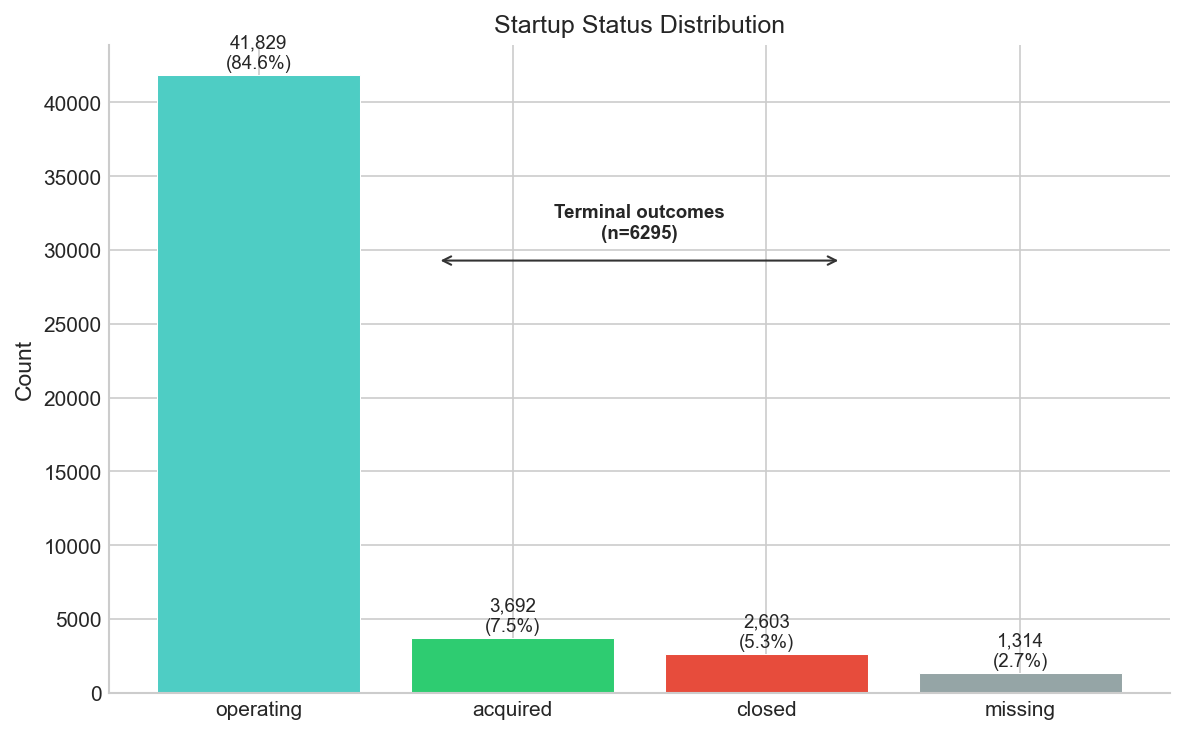

In [8]:
# Figure 1: Target Distribution
fig, ax = plt.subplots(figsize=(8, 5))
status_counts = df['status'].value_counts(dropna=False)
order = ['operating', 'acquired', 'closed']
counts = [status_counts.get(s, 0) for s in order]
nan_count = df['status'].isna().sum()

colors = ['#4ECDC4', '#2ECC71', '#E74C3C', '#95A5A6']
bars = ax.bar(order + ['missing'], counts + [nan_count], color=colors, edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, counts + [nan_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# Bracket for terminal subset
ax.annotate('', xy=(0.7, max(counts)*0.7), xytext=(2.3, max(counts)*0.7),
            arrowprops=dict(arrowstyle='<->', color='#333'))
ax.text(1.5, max(counts)*0.73, f'Terminal outcomes\n(n={sum(counts[1:])})', 
        ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Startup Status Distribution')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_target_distribution.png', bbox_inches='tight')
plt.show()

### 2.3.2 Missingness Heatmap

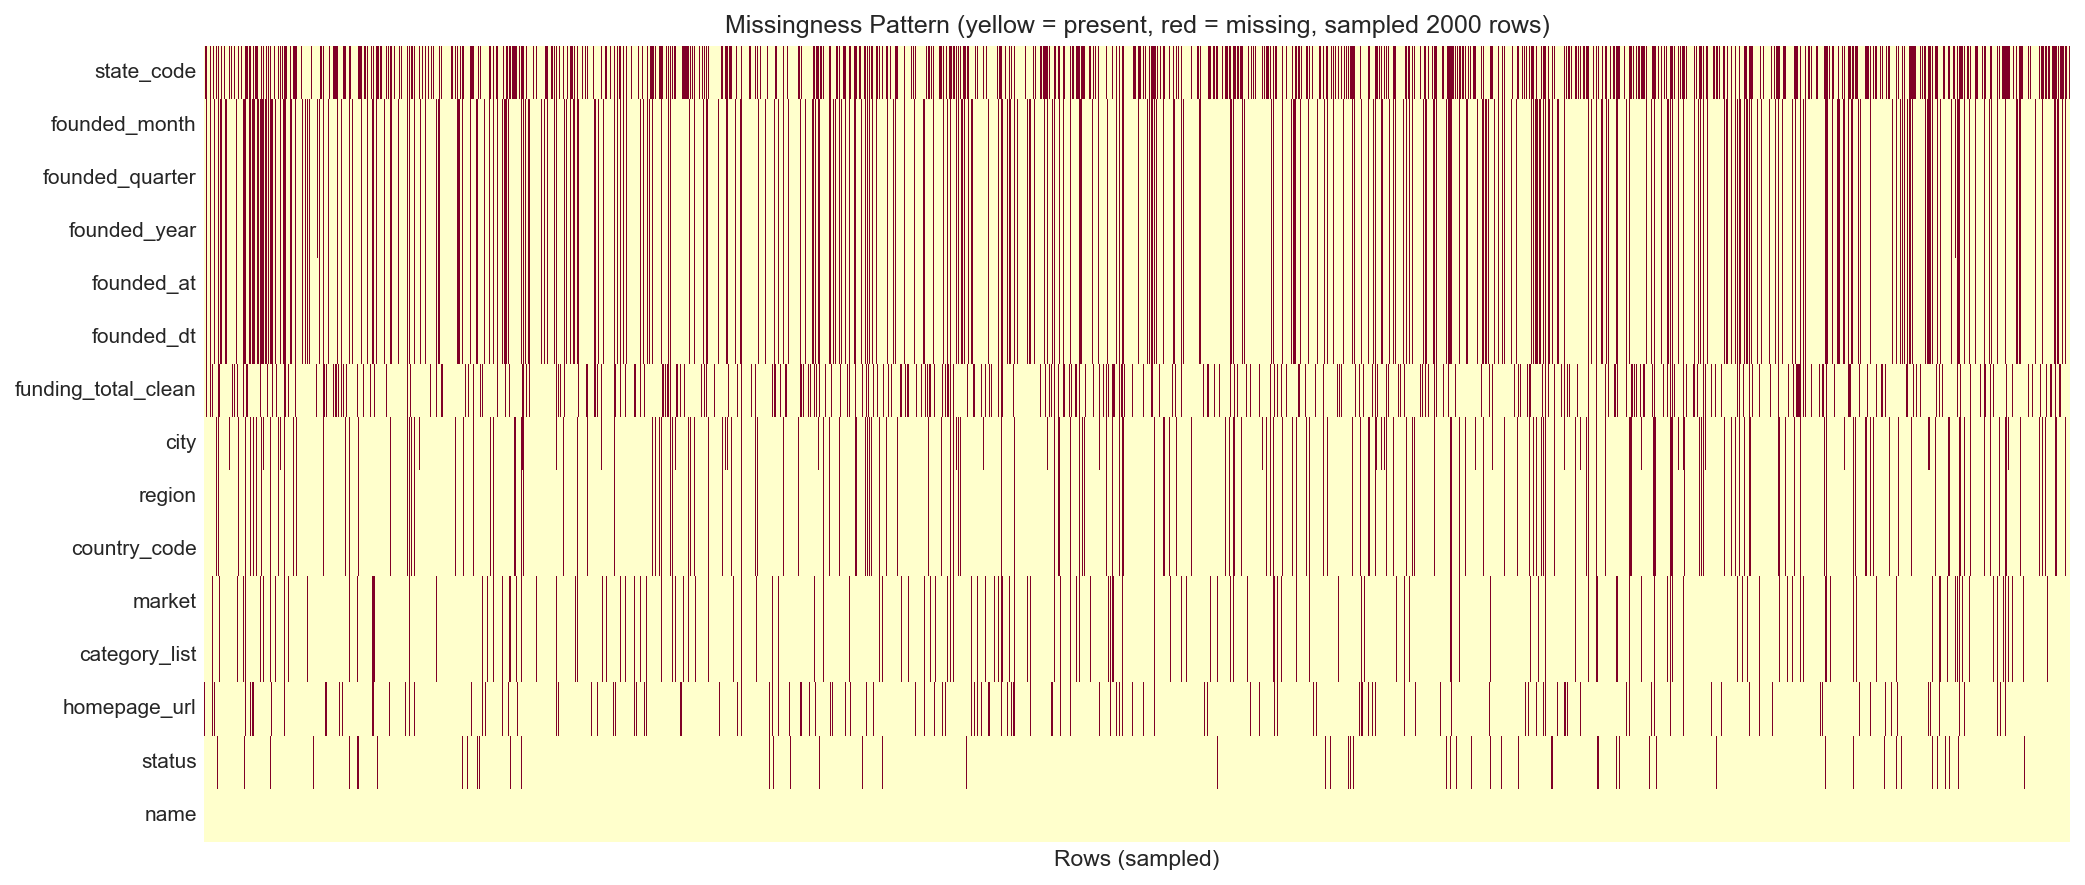

In [9]:
# Figure 2: Missingness Heatmap
fig, ax = plt.subplots(figsize=(14, 6))
miss_cols = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
miss_cols = miss_cols[miss_cols > 0]
miss_matrix = df[miss_cols.index].isna().astype(int)
sample_idx = np.random.RandomState(SEED).choice(len(df), size=min(2000, len(df)), replace=False)
sample_idx.sort()
sns.heatmap(miss_matrix.iloc[sample_idx].T, cbar=False, cmap='YlOrRd',
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Missingness Pattern (yellow = present, red = missing, sampled 2000 rows)')
ax.set_xlabel('Rows (sampled)')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_missingness_heatmap.png', bbox_inches='tight')
plt.show()

### 2.3.3 Funding Distribution by Outcome (violin/box, log scale)

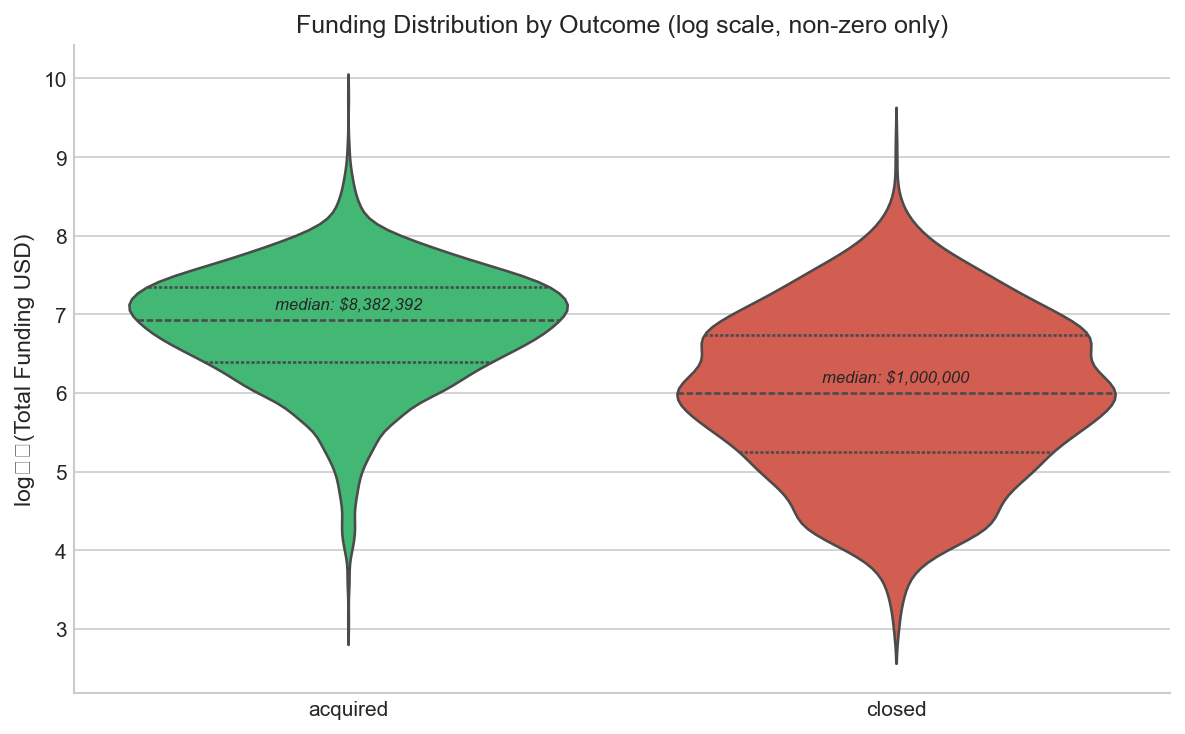

In [10]:
# Figure 3: Funding Distribution by Outcome
fig, ax = plt.subplots(figsize=(8, 5))
term_funding = terminal[terminal['funding_total_clean'] > 0].copy()
term_funding['log_funding'] = np.log10(term_funding['funding_total_clean'])
palette = {'acquired': '#2ECC71', 'closed': '#E74C3C'}
sns.violinplot(data=term_funding, x='status', y='log_funding', palette=palette,
               inner='quartile', ax=ax, order=['acquired', 'closed'])
ax.set_ylabel('log₁₀(Total Funding USD)')
ax.set_xlabel('')
ax.set_title('Funding Distribution by Outcome (log scale, non-zero only)')
medians = term_funding.groupby('status')['log_funding'].median()
for i, status in enumerate(['acquired', 'closed']):
    ax.text(i, medians[status] + 0.15, f'median: ${10**medians[status]:,.0f}',
            ha='center', fontsize=8, fontstyle='italic')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_funding_by_outcome.png', bbox_inches='tight')
plt.show()

### 2.3.4 Funding Round Progression Ladder

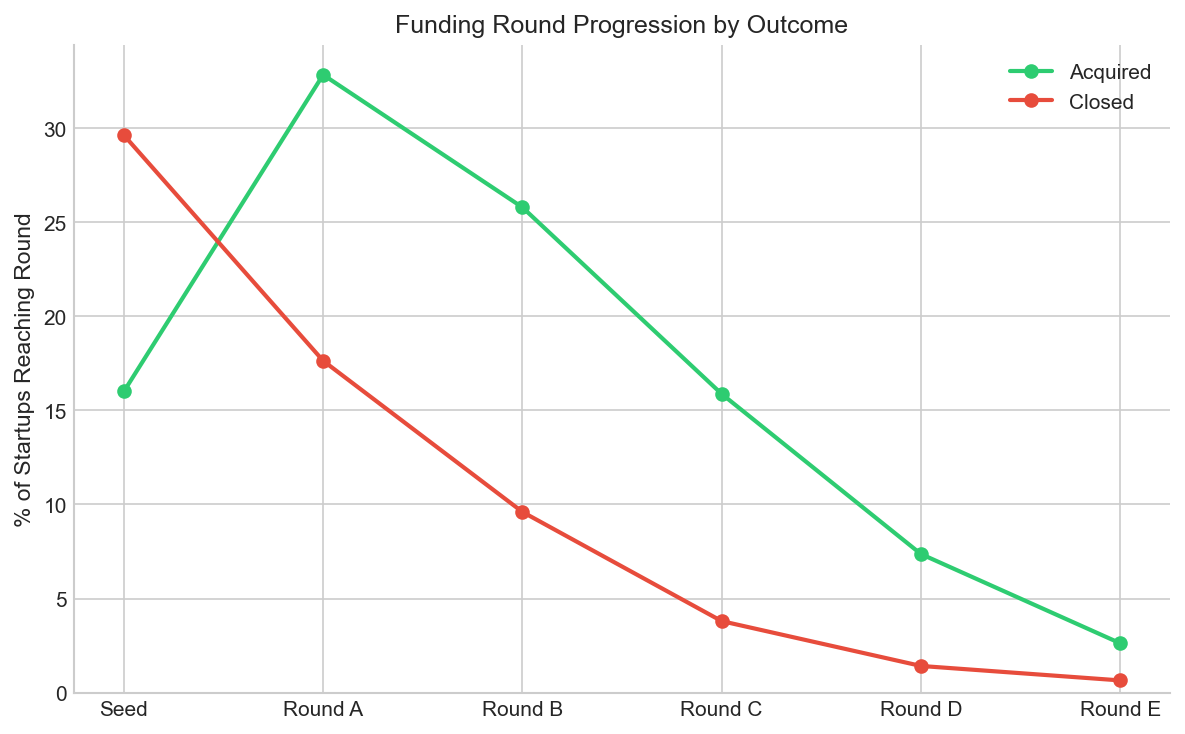

In [11]:
# Figure 4: Funding Round Progression Ladder
round_cols = ['seed', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E']
fig, ax = plt.subplots(figsize=(8, 5))
for status, color, label in [('acquired', '#2ECC71', 'Acquired'), ('closed', '#E74C3C', 'Closed')]:
    subset = terminal[terminal['status'] == status]
    pcts = [(subset[c] > 0).mean() * 100 for c in round_cols]
    ax.plot(range(len(round_cols)), pcts, 'o-', color=color, label=label, linewidth=2, markersize=6)
ax.set_xticks(range(len(round_cols)))
ax.set_xticklabels(['Seed', 'Round A', 'Round B', 'Round C', 'Round D', 'Round E'])
ax.set_ylabel('% of Startups Reaching Round')
ax.set_title('Funding Round Progression by Outcome')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/04_funding_round_ladder.png', bbox_inches='tight')
plt.show()

### 2.3.5 Geographic Distribution (top-15 countries)

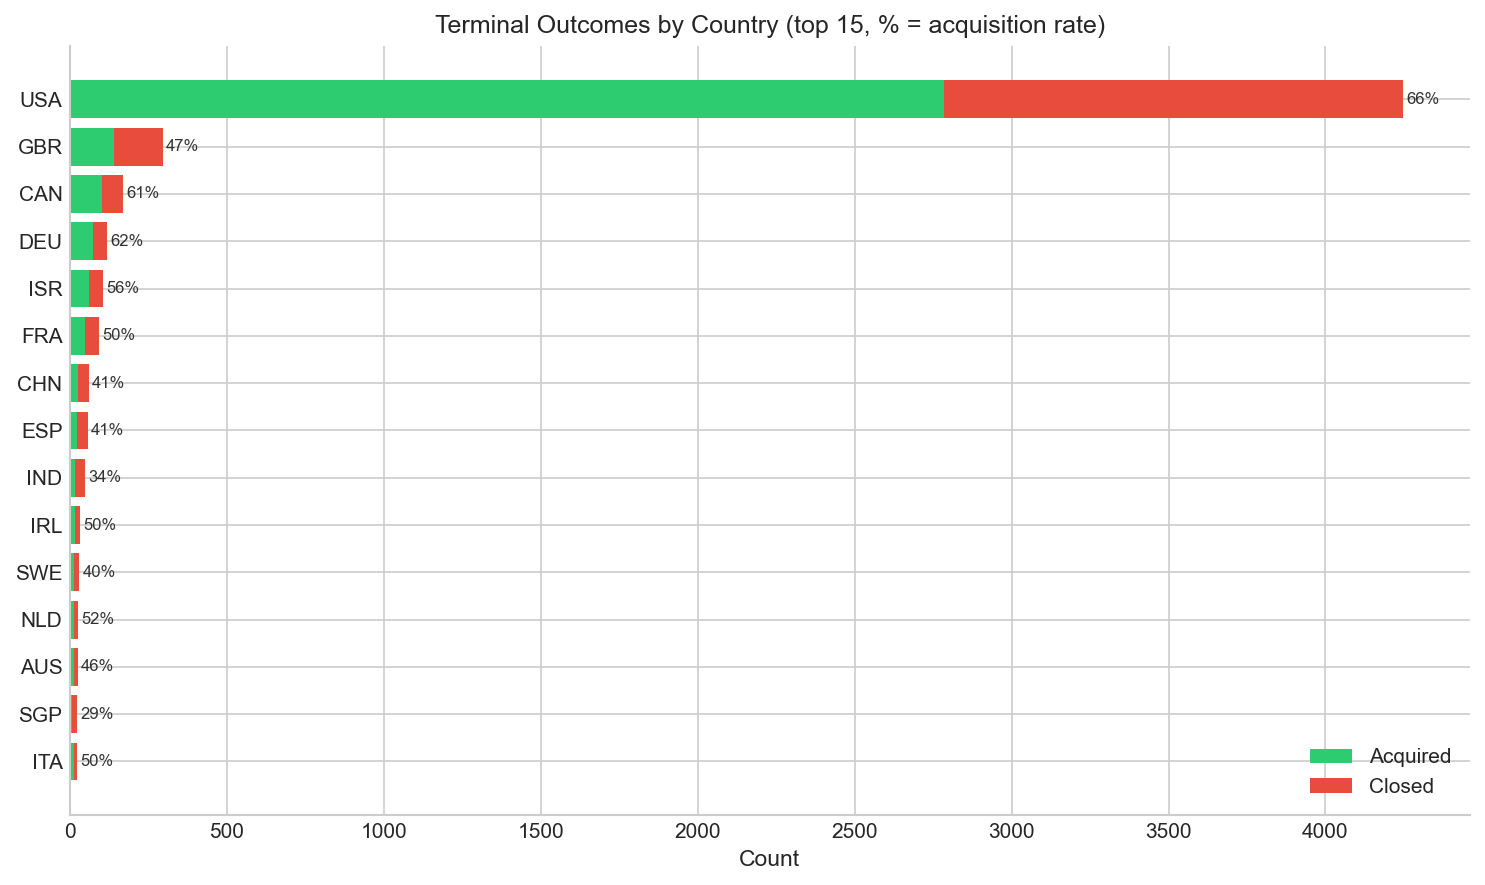

In [12]:
# Figure 5: Geographic Distribution (top-15 countries)
fig, ax = plt.subplots(figsize=(10, 6))
country_outcome = terminal.groupby(['country_code', 'status']).size().unstack(fill_value=0)
country_outcome['total'] = country_outcome.sum(axis=1)
top15 = country_outcome.nlargest(15, 'total')
top15['acq_rate'] = top15['acquired'] / top15['total'] * 100
top15 = top15.sort_values('total', ascending=True)
ax.barh(range(len(top15)), top15['acquired'], color='#2ECC71', label='Acquired')
ax.barh(range(len(top15)), top15['closed'], left=top15['acquired'], color='#E74C3C', label='Closed')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['total'] + 10, i, f'{row["acq_rate"]:.0f}%', va='center', fontsize=8, color='#333')
ax.set_xlabel('Count')
ax.set_title('Terminal Outcomes by Country (top 15, % = acquisition rate)')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/05_geographic_distribution.png', bbox_inches='tight')
plt.show()

### 2.3.6 Market Sector Breakdown (top-20)

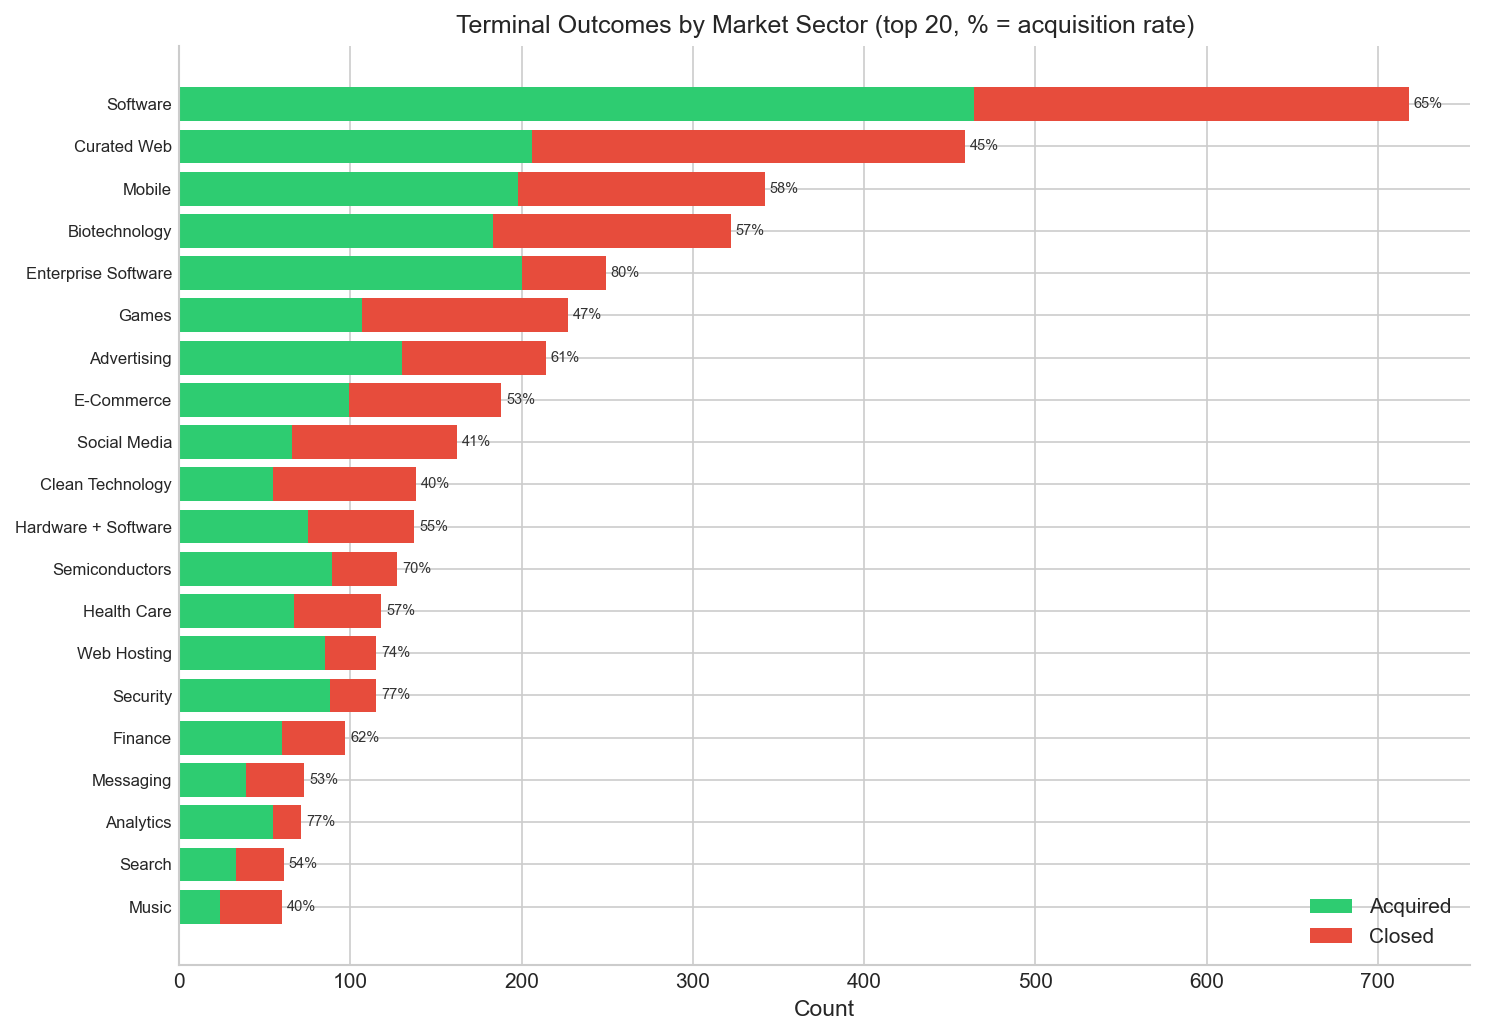

In [13]:
# Figure 6: Market Sector Breakdown (top-20)
fig, ax = plt.subplots(figsize=(10, 7))
market_clean = terminal['market'].str.strip()
mkt_outcome = terminal.assign(market_clean=market_clean).groupby(['market_clean', 'status']).size().unstack(fill_value=0)
mkt_outcome['total'] = mkt_outcome.sum(axis=1)
top20 = mkt_outcome.nlargest(20, 'total').sort_values('total', ascending=True)
top20['acq_rate'] = top20['acquired'] / top20['total'] * 100
ax.barh(range(len(top20)), top20['acquired'], color='#2ECC71', label='Acquired')
ax.barh(range(len(top20)), top20['closed'], left=top20['acquired'], color='#E74C3C', label='Closed')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=8)
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['total'] + 3, i, f'{row["acq_rate"]:.0f}%', va='center', fontsize=7, color='#333')
ax.set_xlabel('Count')
ax.set_title('Terminal Outcomes by Market Sector (top 20, % = acquisition rate)')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/06_market_sector_breakdown.png', bbox_inches='tight')
plt.show()

### 2.3.7 Founding Year Cohort Plot

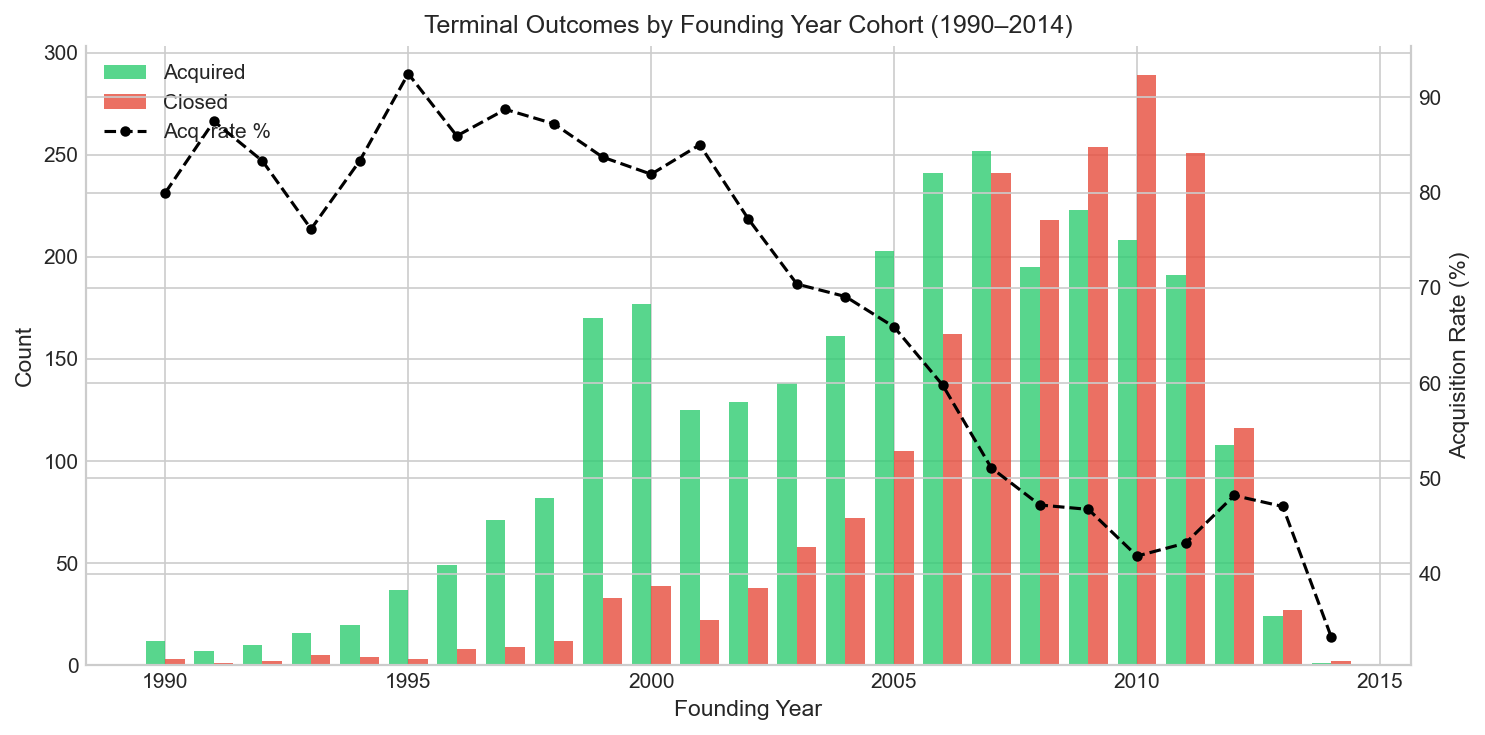

In [14]:
# Figure 7: Founding Year Cohort Plot
fig, ax = plt.subplots(figsize=(10, 5))

term_fy = terminal[terminal['founded_dt'].notna()].copy()
term_fy['founded_year'] = term_fy['founded_dt'].dt.year
term_fy = term_fy[(term_fy['founded_year'] >= 1990) & (term_fy['founded_year'] <= 2014)]

cohort = term_fy.groupby(['founded_year', 'status']).size().unstack(fill_value=0)
cohort['total'] = cohort.sum(axis=1)
cohort['acq_rate'] = cohort['acquired'] / cohort['total'] * 100

ax2 = ax.twinx()
ax.bar(cohort.index - 0.2, cohort['acquired'], width=0.4, color='#2ECC71', label='Acquired', alpha=0.8)
ax.bar(cohort.index + 0.2, cohort['closed'], width=0.4, color='#E74C3C', label='Closed', alpha=0.8)
ax2.plot(cohort.index, cohort['acq_rate'], 'k--o', markersize=4, linewidth=1.5, label='Acq. rate %')

ax.set_xlabel('Founding Year')
ax.set_ylabel('Count')
ax2.set_ylabel('Acquisition Rate (%)')
ax.set_title('Terminal Outcomes by Founding Year Cohort (1990–2014)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/07_founding_year_cohort.png', bbox_inches='tight')
plt.show()

### 2.3.8 Correlation Heatmap (numeric features)

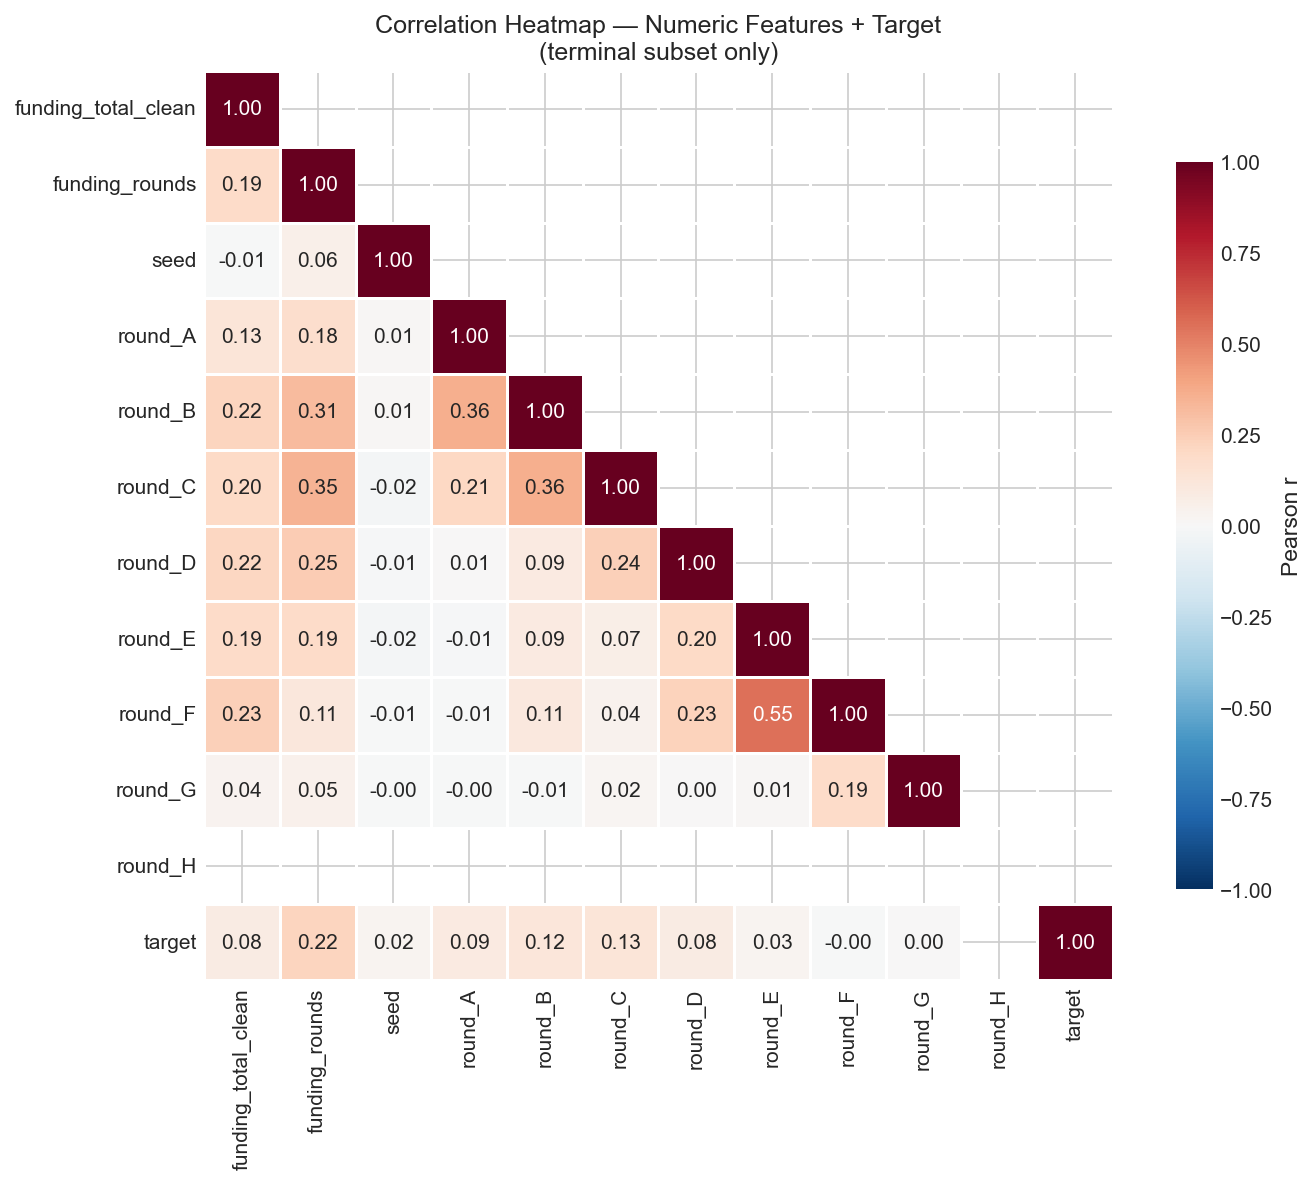

In [15]:
# Figure 8: Correlation Heatmap (numeric features, terminal subset)
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['funding_total_clean', 'funding_rounds', 'seed', 'round_A', 'round_B',
                'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']
avail_cols = [c for c in numeric_cols if c in terminal.columns]
corr = terminal[avail_cols + ['target']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation Heatmap — Numeric Features + Target\n(terminal subset only)')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 2.3.9 Horizon-Risk Visual

Model feature counts: H1=9, H2=9, H3=31
Note: H2 gains derived time-to-first-funding feature in Phase 3


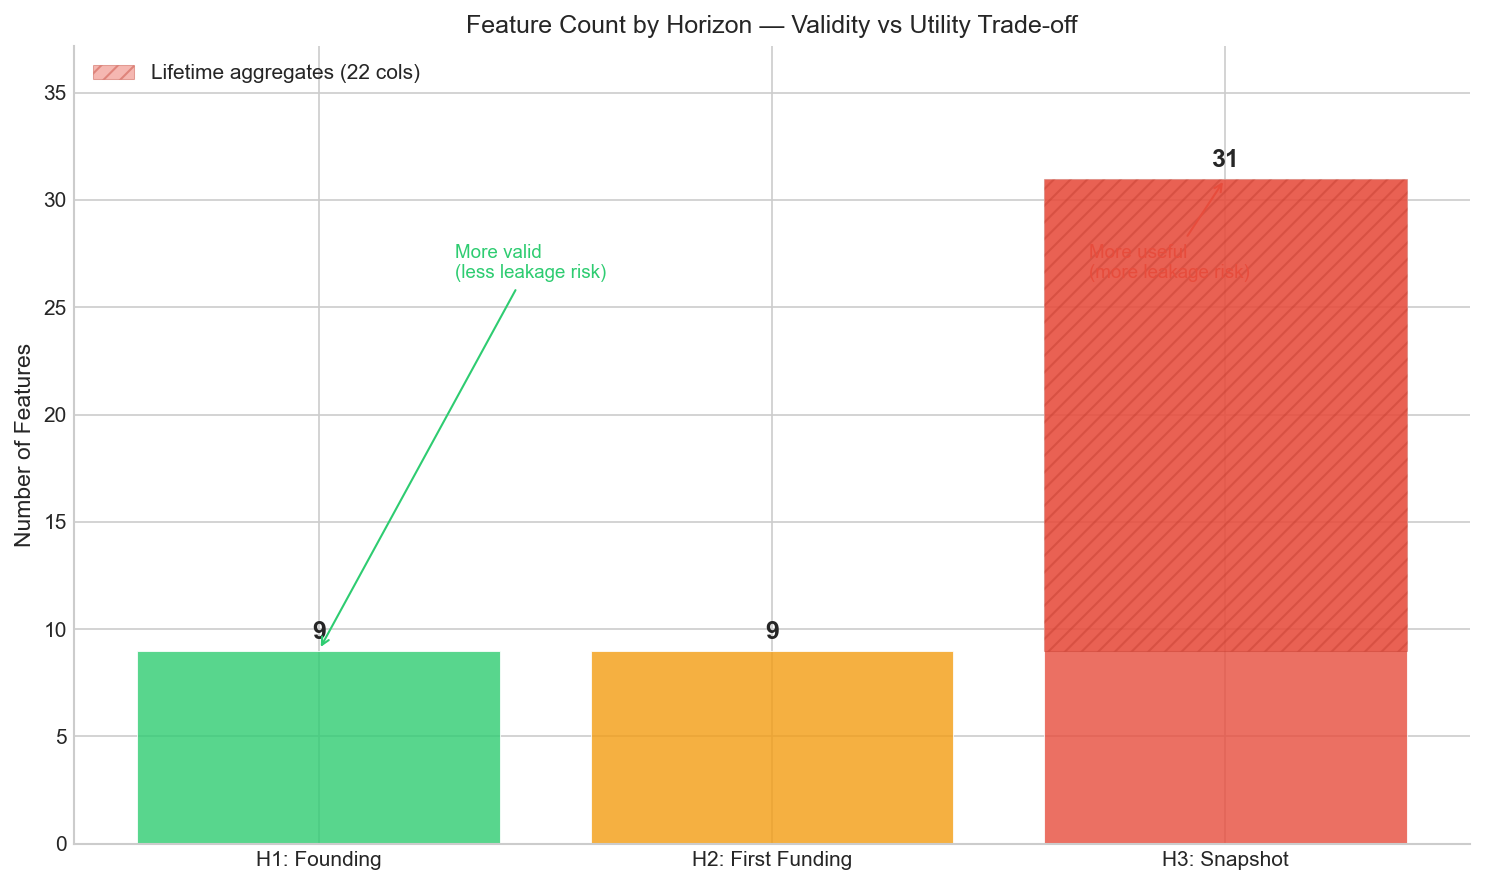

In [16]:
# Figure 9: Horizon-Risk Visual
fig, ax = plt.subplots(figsize=(10, 6))

horizons_list = ['H1: Founding', 'H2: First Funding', 'H3: Snapshot']

# Count only columns that enter the model as features
# Exclude FORBIDDEN and derive-then-drop columns (founded_at, first_funding_at)
derive_drop = [col for col, info in LEAK_REGISTRY.items() if info['decision'] == 'derive']
h1_feats = [c for c in FOUNDING_SAFE if c not in FORBIDDEN and c not in derive_drop]
h2_feats = [c for c in FIRST_FUNDING_SAFE if c not in FORBIDDEN and c not in derive_drop]
h3_feats = [c for c in SNAPSHOT_ALL if c not in FORBIDDEN and c not in derive_drop]
n_features = [len(h1_feats), len(h2_feats), len(h3_feats)]
print(f'Model feature counts: H1={n_features[0]}, H2={n_features[1]}, H3={n_features[2]}')
print(f'Note: H2 gains derived time-to-first-funding feature in Phase 3')

# Count lifetime aggregate columns (H3-only)
leak_count = sum(1 for col, info in LEAK_REGISTRY.items() if info['decision'] == 'include_h3_only')

bar_colors = ['#2ECC71', '#F39C12', '#E74C3C']
bars = ax.bar(horizons_list, n_features, color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.8)

for bar, n in zip(bars, n_features):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(n), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.bar(horizons_list[2], leak_count, bottom=n_features[2]-leak_count,
       color='#E74C3C', alpha=0.4, hatch='///', edgecolor='#C0392B', linewidth=0.5,
       label=f'Lifetime aggregates ({leak_count} cols)')

ax.set_ylabel('Number of Features')
ax.set_title('Feature Count by Horizon — Validity vs Utility Trade-off')
ax.legend(loc='upper left')

ax.annotate('More valid\n(less leakage risk)', xy=(0, n_features[0]),
            xytext=(0.3, max(n_features)*0.85),
            arrowprops=dict(arrowstyle='->', color='#2ECC71'), fontsize=9, color='#2ECC71')
ax.annotate('More useful\n(more leakage risk)', xy=(2, n_features[2]),
            xytext=(1.7, max(n_features)*0.85),
            arrowprops=dict(arrowstyle='->', color='#E74C3C'), fontsize=9, color='#E74C3C')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(n_features) * 1.2)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/09_horizon_risk_visual.png', bbox_inches='tight')
plt.show()

### 2.3.10 Feature-Horizon Availability Table

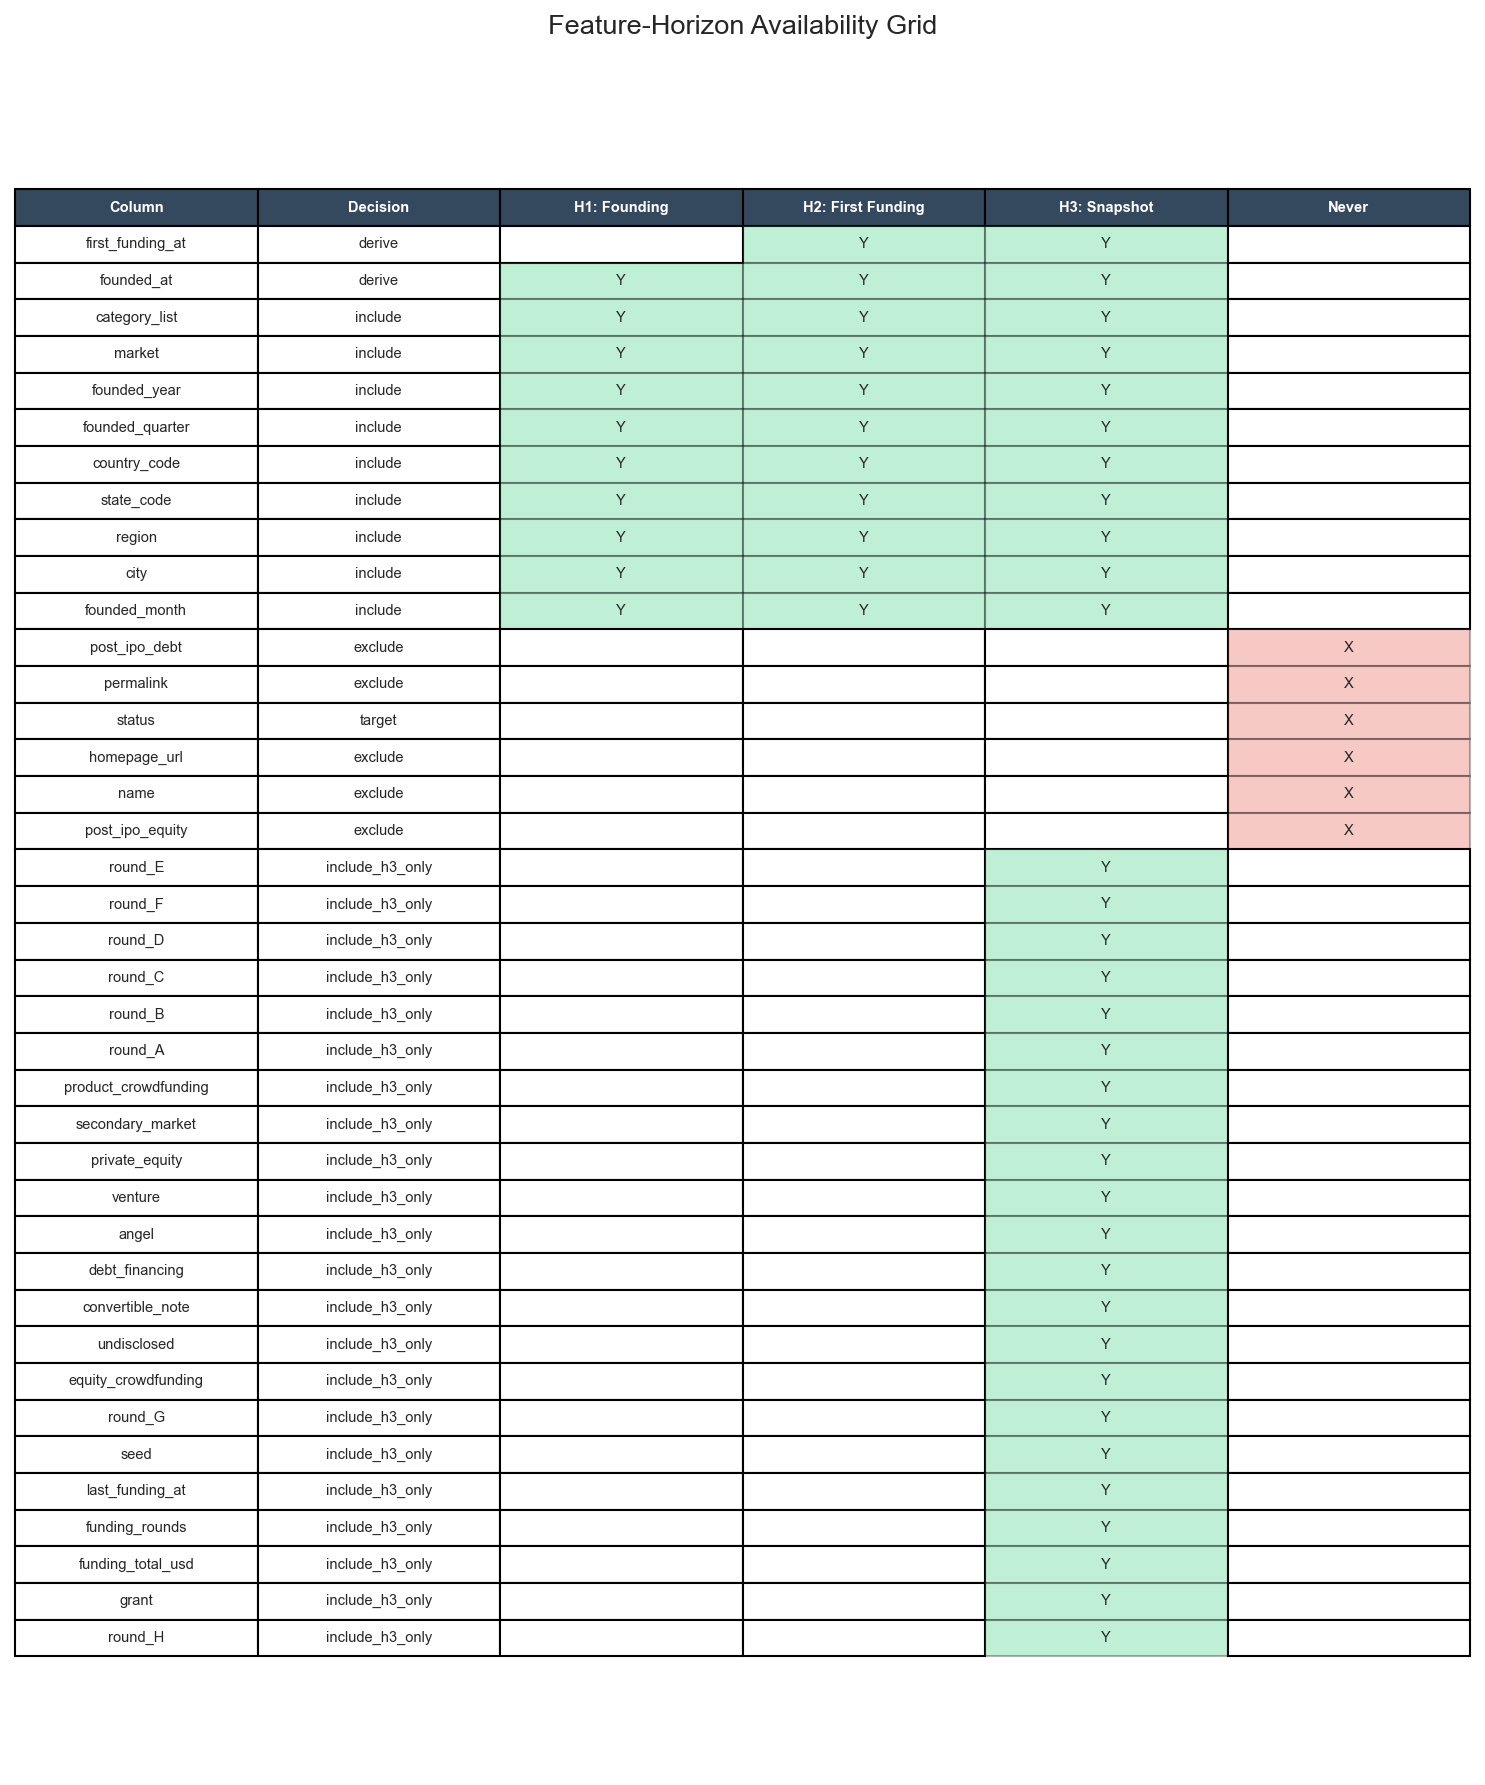

In [17]:
# Figure 10: Feature-Horizon Availability Table
fig, ax = plt.subplots(figsize=(10, 12))
ax.axis('off')

leak_df = pd.DataFrame(LEAK_REGISTRY).T
leak_df.index.name = 'column'
cols_sorted = leak_df.sort_values('safe_at')
horizons = ['founding', 'first_funding', 'snapshot', 'never']
horizon_labels = ['H1: Founding', 'H2: First Funding', 'H3: Snapshot', 'Never']

grid_data = []
for col, row in cols_sorted.iterrows():
    avail = []
    safe = row['safe_at']
    for h in horizons:
        if h == 'never':
            avail.append('X' if safe == 'never' else '')
        elif safe == 'founding':
            avail.append('Y')
        elif safe == 'first_funding':
            avail.append('Y' if h in ['first_funding', 'snapshot'] else '')
        elif safe == 'snapshot':
            avail.append('Y' if h == 'snapshot' else '')
        else:
            avail.append('')
    grid_data.append([col, row['decision']] + avail)

table = ax.table(cellText=grid_data, colLabels=['Column', 'Decision'] + horizon_labels,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 1.2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#34495E')
        cell.set_text_props(color='white', fontweight='bold')
    elif col >= 2:
        text = cell.get_text().get_text()
        if text == 'Y':
            cell.set_facecolor('#2ECC71')
            cell.set_alpha(0.3)
        elif text == 'X':
            cell.set_facecolor('#E74C3C')
            cell.set_alpha(0.3)
ax.set_title('Feature-Horizon Availability Grid', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/10_feature_horizon_grid.png', bbox_inches='tight')
plt.show()

### 2.3.11 Time-to-First-Funding Distribution by Outcome

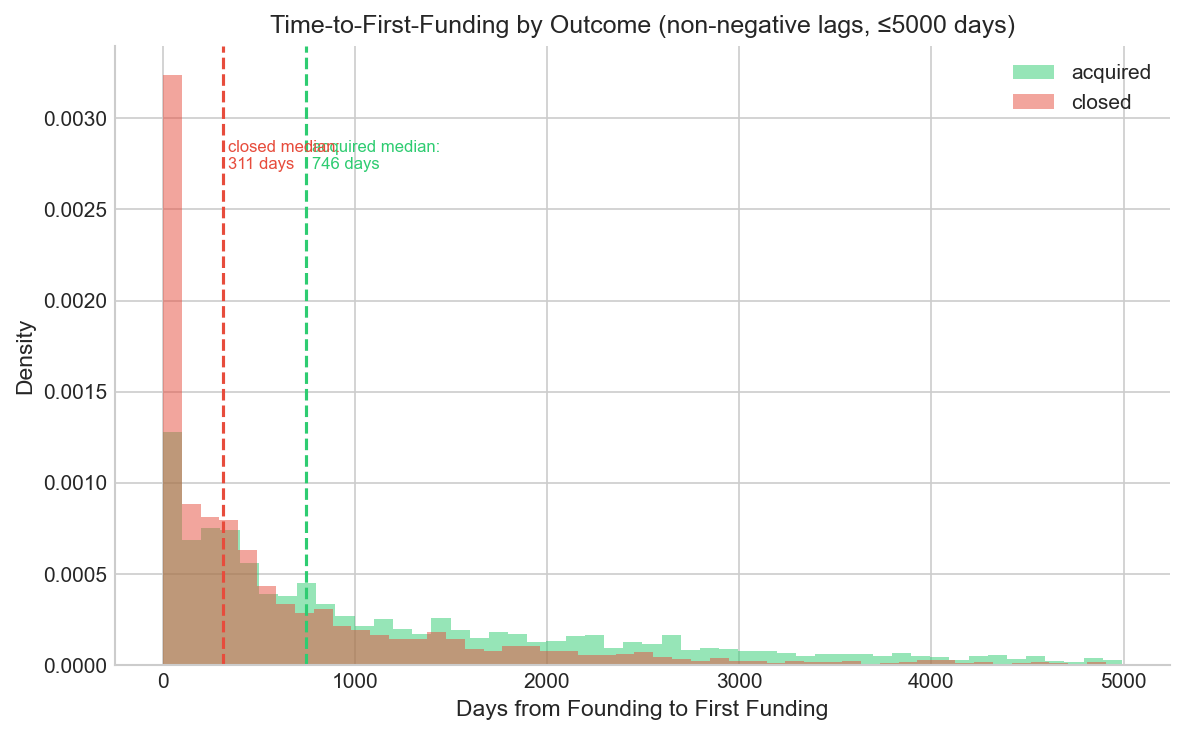

In [18]:
# Figure 11: Time-to-First-Funding Distribution by Outcome
fig, ax = plt.subplots(figsize=(8, 5))
ttff = terminal.copy()
ttff['ttff_days'] = (ttff['first_funding_dt'] - ttff['founded_dt']).dt.days
valid_ttff = ttff[(ttff['ttff_days'].notna()) & (ttff['ttff_days'] >= 0) & (ttff['ttff_days'] <= 5000)]
for status, color in [('acquired', '#2ECC71'), ('closed', '#E74C3C')]:
    subset = valid_ttff[valid_ttff['status'] == status]
    ax.hist(subset['ttff_days'], bins=50, alpha=0.5, color=color, label=status, density=True)
medians_ttff = valid_ttff.groupby('status')['ttff_days'].median()
for status, color in [('acquired', '#2ECC71'), ('closed', '#E74C3C')]:
    ax.axvline(medians_ttff[status], color=color, linestyle='--', linewidth=1.5)
    ax.text(medians_ttff[status]+30, ax.get_ylim()[1]*0.8,
            f'{status} median:\n{medians_ttff[status]:.0f} days', fontsize=8, color=color)
ax.set_xlabel('Days from Founding to First Funding')
ax.set_ylabel('Density')
ax.set_title('Time-to-First-Funding by Outcome (non-negative lags, ≤5000 days)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/11_time_to_first_funding.png', bbox_inches='tight')
plt.show()

### 2.3.12 Date Validity Check (founded_at vs first_funding_at)

Dropped 74 rows with dates outside 1900-2025 (malformed date artefacts)


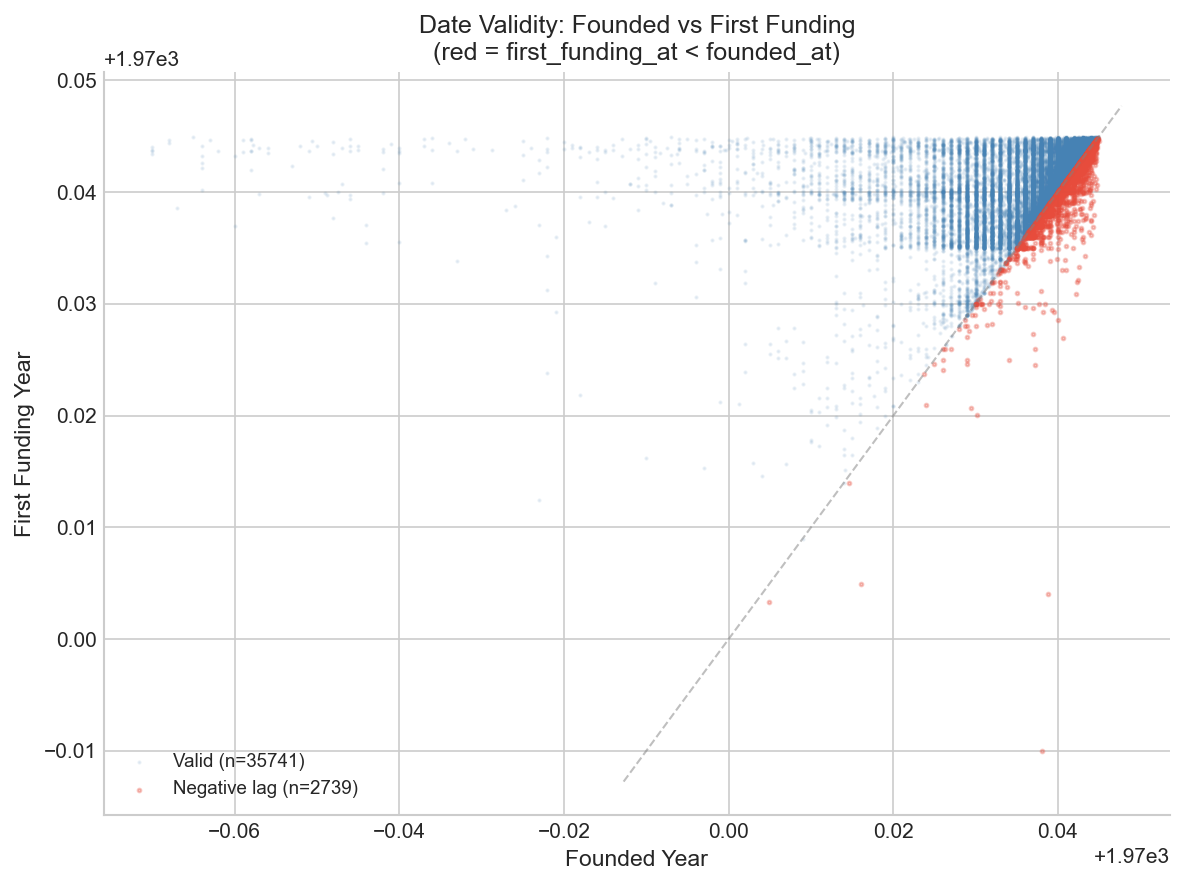

In [19]:
# Figure 12: Date Validity Check
# Plot using numeric years (not datetime) to avoid matplotlib date range errors
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 6))

date_check = df[df['founded_dt'].notna() & df['first_funding_dt'].notna()].copy()

# Filter out rows with dates outside 1900-2025 (67+ malformed entries)
min_date = pd.Timestamp('1900-01-01')
max_date = pd.Timestamp('2025-12-31')
n_before = len(date_check)
date_check = date_check[
    (date_check['founded_dt'] >= min_date) & (date_check['founded_dt'] <= max_date) &
    (date_check['first_funding_dt'] >= min_date) & (date_check['first_funding_dt'] <= max_date)
].copy()
n_dropped = n_before - len(date_check)
print(f"Dropped {n_dropped} rows with dates outside 1900-2025 (malformed date artefacts)")

# Convert to plain floats - avoids matplotlib datetime converter entirely
founded_yr = (date_check['founded_dt'].astype(np.int64) / 1e9 / 86400 / 365.25 + 1970).values
funding_yr = (date_check['first_funding_dt'].astype(np.int64) / 1e9 / 86400 / 365.25 + 1970).values
lag_days = (date_check['first_funding_dt'] - date_check['founded_dt']).dt.days.values

valid_mask = lag_days >= 0
invalid_mask = lag_days < 0

ax.scatter(founded_yr[valid_mask], funding_yr[valid_mask],
           s=1, alpha=0.1, color='steelblue', label=f'Valid (n={valid_mask.sum()})')
ax.scatter(founded_yr[invalid_mask], funding_yr[invalid_mask],
           s=3, alpha=0.3, color='#E74C3C', label=f'Negative lag (n={invalid_mask.sum()})')

# Diagonal reference line (y = x)
lo = max(ax.get_xlim()[0], ax.get_ylim()[0])
hi = min(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], '--', color='grey', alpha=0.5, linewidth=1)

ax.set_xlabel('Founded Year')
ax.set_ylabel('First Funding Year')
ax.set_title('Date Validity: Founded vs First Funding\n(red = first_funding_at < founded_at)')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/12_date_validity_check.png', bbox_inches='tight')
plt.show()

## 2.4 EDA Summary and Key Findings

**Data Quality:**
- 54,294 raw rows → 49,438 after removing 4,856 blank rows; 4 genuine duplicate rows found (2 pairs), 2 removed by the cleaning pipeline → 49,436 cleaned rows
- `funding_total_usd` requires parsing: Indian-style commas, leading spaces, dash-as-missing
- 2,739 rows with impossible negative funding lags (cleaning pipeline count, after out-of-range date filtering) — requires quarantine decision
- Missingness is structured: founding dates ~29%, geography 16–44%, funding columns clean after blank removal

**Target Variable:**
- 6,295 terminal-outcome startups (59% acquired, 41% closed) — mildly imbalanced but workable
- 41,827 operating firms excluded as right-censored (after dedup); 1,314 rows with missing status also excluded

**Key Patterns:**
- Acquired startups have substantially higher total funding (median ~$10M vs ~$1M for closed)
- Funding round progression ladder shows clear separation: acquired firms reach later rounds at much higher rates
- USA dominates the dataset (~75% of terminal cases) with a ~60% acquisition rate
- Founding year cohort analysis reveals temporal patterns that justify the chronological train/val/test split
- Funding aggregates (H3 features) show strong outcome separation — this is the leakage signal the horizon framework is designed to control
- Founding-time features (H1) show much weaker separation — the honest signal is modest
- Time-to-first-funding shows slight differences by outcome, supporting H2 as a meaningful intermediate horizon